In [1]:
import os
import re
import matplotlib.pyplot as plt

from pyulog import ULog
import pandas as pd
from pyulog.px4_events import PX4Events
from pyulog.px4 import PX4ULog
from pyulog.extract_message import extract_message

In [ ]:
def extract_force_from_file(file_path):
    """
    주어진 텍스트 로그 파일에서 "[INFO] Maximum contact force: <value> N" 메시지를 찾아,
    해당 force 값을 반환합니다.

    Parameters:
        file_path (str): 로그 파일 경로.

    Returns:
        float or None: force 값이 추출되면 float, 없으면 None.
    """
    force_value = None
    pattern = re.compile(r"\[INFO\] Maximum contact force:\s*([0-9.]+)\s*N")

    try:
        with open(file_path, 'r') as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    force_value = float(match.group(1))
                    break  # 한 파일에 하나의 force 값만 있다고 가정
    except Exception as e:
        print(f"파일을 읽는 중 오류 발생: {file_path}\n{e}")

    return force_value

In [ ]:
def getUlgEvents(ulog):
    """
    ULog 객체에서 PX4 이벤트 메시지를 추출합니다.

    Parameters:
        ulog (ULog): ULog 객체.

    Returns:
        list: (timestamp, label, message) 튜플들의 리스트.
    """
    px4_ulog = PX4Events()

    def default_json_definitions_cb(already_has_default_parser: bool):
        raise AssertionError('Must use definitions from logs')

    px4_ulog.set_default_json_definitions_cb(default_json_definitions_cb)
    messages = px4_ulog.get_logged_events(ulog)
    return messages

In [ ]:
def extract_from_log(log_file_path):
    """
    단일 로그 파일을 한 줄씩 읽으면서, 앞에 있는 timestamp와 함께 두 종류의 메시지를 파싱합니다.
    1. "[INFO] Maximum contact force: <value> N" 메시지 -> force 값 추출.
    2. "[INFO] Bias applied. Amount: {x: <x> y: <y> z: <z>}" 메시지 -> 각 축 bias 값 추출.

    Parameters:
        log_file_path (str): 로그 파일 경로.

    Returns:
        tuple: (force_data, bias_data)
            - force_data: [(timestamp, force_value), ...]
            - bias_data: [(timestamp, bias_x, bias_y, bias_z), ...]
    """
    # 정규표현식 패턴 정의
    timestamp_pattern = re.compile(r"\[\s*([0-9.]+)\|")
    force_pattern = re.compile(r"Maximum contact force:\s*([0-9.]+)\s*N")
    pattern = r"INFO\s+\[logger\]\s+Opened full log file:\s+(.*\.ulg)"

    ulg_file_name = None
    contact_data = []
    arm_data = []

    with open(log_file_path, 'r') as f:
        for line in f:
            ts_match = timestamp_pattern.search(line)
            timestamp = float(ts_match.group(1)) if ts_match else None

            match = re.search(pattern, line)
            if match:
                ulg_file_name = os.path.basename(match.group(1))

            if "Maximum contact force" in line:
                force_match = force_pattern.search(line)
                if force_match and timestamp is not None:
                    force_value = float(force_match.group(1))
                    contact_data.append((timestamp, force_value))

            if ""

    return  ulg_file_name, contact_data, arm_data

In [ ]:
# 지정된 경로에서 .ulg 파일 열기
    ulg_full_path = os.path.join(base_dir, ulg_file_name)
    if os.path.exists(ulg_full_path):
        try:
            ulog = ULog(ulg_full_path)
            print(f"ULG 파일을 성공적으로 열었습니다: {ulg_full_path}")
            messages = getUlgEvents(ulog)
            for timestamp, label, message in messages:
                if "Armed by external command" in message:
                    print(f"'Armed by external command' 메시지가 발견된 timestamp: {timestamp}")
            return ulog
        except Exception as e:
            print(f"파일 열기 중 오류 발생: {e}")
            return None
    else:
        print(f"지정된 경로에서 ULG 파일을 찾을 수 없습니다: {ulg_full_path}")
        return None

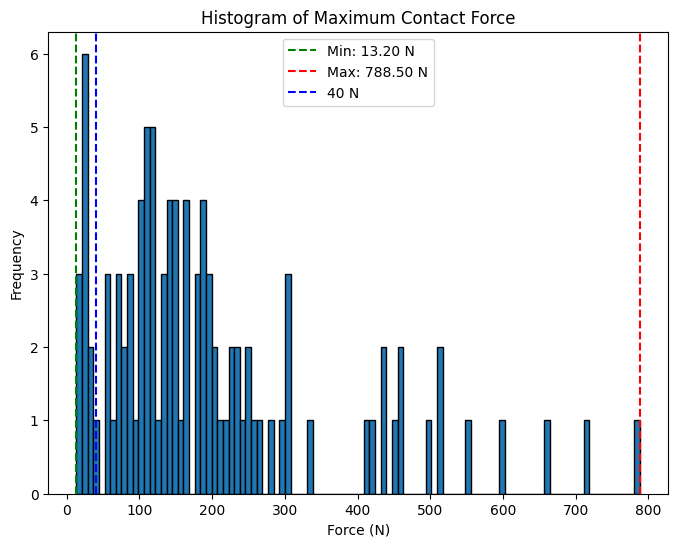

Successful landing count: 3
Unsuccessful landing count: 97
landings under 50N: 12
landings over 50N: 88
landings under 40N: 11
landings over 40N: 89


In [ ]:
# 로그 파일들이 있는 상위 경로 (사용자 홈 경로 ~ 를 확장)
base_path = os.path.expanduser("~/PX4-Autopilot/__temp/2025-03-03T19-56-42Z")

# 모든 가속도 값을 저장할 리스트
accelerations = []

# 디렉토리 이름은 "000"부터 "999"까지 (문자열로 3자리 포맷)
for i in range(1, 1000):  # 만약 총 파일 수가 100개라면, range(100)으로 조정 가능
    dir_name = f"{i:03d}"  # 3자리 zero padding
    # 파일 경로 생성: ~/PX4-Autopilot/logs/2025-03-10T17-34-40Z/{dir_name}/iris/Normal_hold_20m/log-combined.log_plain.log
    file_path = os.path.join(base_path, dir_name, "iris", "Normal_hold_20m", "log-combined.log_plain.log")

    # 파일 존재 여부 체크
    if os.path.exists(file_path):
        acceleration = extract_from_log(file_path)
        if acceleration is not None:
            accelerations.append(acceleration)

        ulog_obj = open_ulg_file_from_log(file_path)
        if ulog_obj is not None:
            velocities.append(ulog_obj)  # 예시: 실제 활용 방식에 맞게 수정하세요.
    else:
        print(f"파일이 존재하지 않습니다: {file_path}")

# 추출한 acceleration 값이 존재하는지 확인
if not accelerations:
    print("추출된 값이 없습니다.")
else:
    # 최소, 최대 값 계산
    min_accel = min(accelerations)
    max_accel = max(accelerations)

    # 히스토그램 그리기
    plt.figure(figsize=(8, 6))
    plt.hist(accelerations, bins=100, edgecolor='black')
    plt.xlabel("Acceleration")
    plt.ylabel("Frequency")
    plt.title("Histogram of Landing Acceleartion Force")

    # 최소, 최대 값에 수직선 표시
    plt.axvline(min_accel, color='green', linestyle='dashed', linewidth=1.5, label=f"Min: {min_accel:.2f} N")
    plt.axvline(max_accel, color='red', linestyle='dashed', linewidth=1.5, label=f"Max: {max_accel:.2f} N")
    plt.legend()

    plt.show()